# Stability in practice: a multiplier-accelerator model


:::{index} single: Stability; introduction
:::

:::{index} Stability; The companion matrix
:::


In [ ]:
import sys
if sys.platform == 'emscripten':  # only in the browser (JupyterLite): install ModelFlow, see mfsetup.py
    %run mfsetup.py
    await install_modelflow()

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from IPython.display import display
from modelhelp import Markdown_html as Markdown   # markdown which also survives the export to pdf

import modeljupytermagic          # provides the %%Makemymodel cell magic

latex = 1   # 1: model graphs are rendered as png, which also works in the pdf build

:::{warning}
This chapter is both unfinished and unpolished. Suggestions are very welcome. Terminology varies very much between
fields of study.
:::

This is the worked example belonging to [Local stability and dynamics](modelflow_stability.md), where the construction is
derived in full. Here a Samuelson multiplier-accelerator model is run through the five classic cases, each one shown as
the position of the roots relative to the unit circle.

## The calculation in one paragraph

ModelFlow differentiates the model around a solved point. That gives the contemporaneous Jacobian $A$ and one lagged
Jacobian $E_i$ for each lag $i = 1 \dots r$. Solving out the contemporaneous block gives
$C_i = (\mathbb{I}-A)^{-1}E_i$, and stacking the lags into the state vector
$\mathbf{z}_t = [\mathbf{y}_t, \mathbf{y}_{t-1}, \dots, \mathbf{y}_{t-r+1}]'$ turns the model into a single first order
system

$$
\Delta\mathbf{z}_t = M\,\Delta\mathbf{z}_{t-1}, \qquad M = (\mathbb{I}-A)^{-1}\bar{E}
$$

where $M$ is the **companion matrix**: the $C_i$ stacked horizontally on top, a rectangular identity underneath. Its
eigenvalues $\lambda$ - which can be complex numbers - answer the stability question:

 - all $\lvert \lambda \rvert < 1$: the system converges, a disturbance dies out
 - at least one $\lvert \lambda \rvert > 1$: the system amplifies, a disturbance grows
 - $\lvert \lambda \rvert = 1$: on the boundary, perpetual undamped movement
 - at least one $\lambda$ with an imaginary part: the system oscillates - dampened if all
   $\lvert \lambda \rvert < 1$, amplifying if any $\lvert \lambda \rvert > 1$

The calculation is carried out by the `newton_diff` class in `modelnewton.py`. An instance is created from a model with
`<modelclass>.get_newton()`; `.get_eigenvalues()` then builds the companion matrix and its eigenvalues for each period,
and `.get_df_eigen_dict()` returns them as a dictionary where the key is the year and the value is a dataframe with the
eigenvalues in the first row and the corresponding eigenvectors below.

The results below do not necessarily give economic meaning. They show how the stability of the system is reflected in the
eigenvalues of the companion matrix.


## The model

The model is written with the `%%Makemymodel` cell magic: lines starting with `>` are ModelFlow equations, the rest is
documentation which is rendered together with them.


In [3]:
%%Makemymodel Mmma
**A Samuelson multiplier-accelerator model**

Output is consumption plus investment:
> gdp = consumption + investment

Consumption is a fraction `mul` of last years output - the multiplier:
> consumption = mul * gdp(-1)

Investment reacts to the change in consumption by the factor `acc` - the accelerator:
> investment = acc * (consumption - consumption(-1)) + exo_investment

**A Samuelson multiplier-accelerator model**

Output is consumption plus investment:
```text
> gdp = consumption + investment
```

Consumption is a fraction `mul` of last years output - the multiplier:
```text
> consumption = mul * gdp(-1)
```

Investment reacts to the change in consumption by the factor `acc` - the accelerator:
```text
> investment = acc * (consumption - consumption(-1)) + exo_investment
```

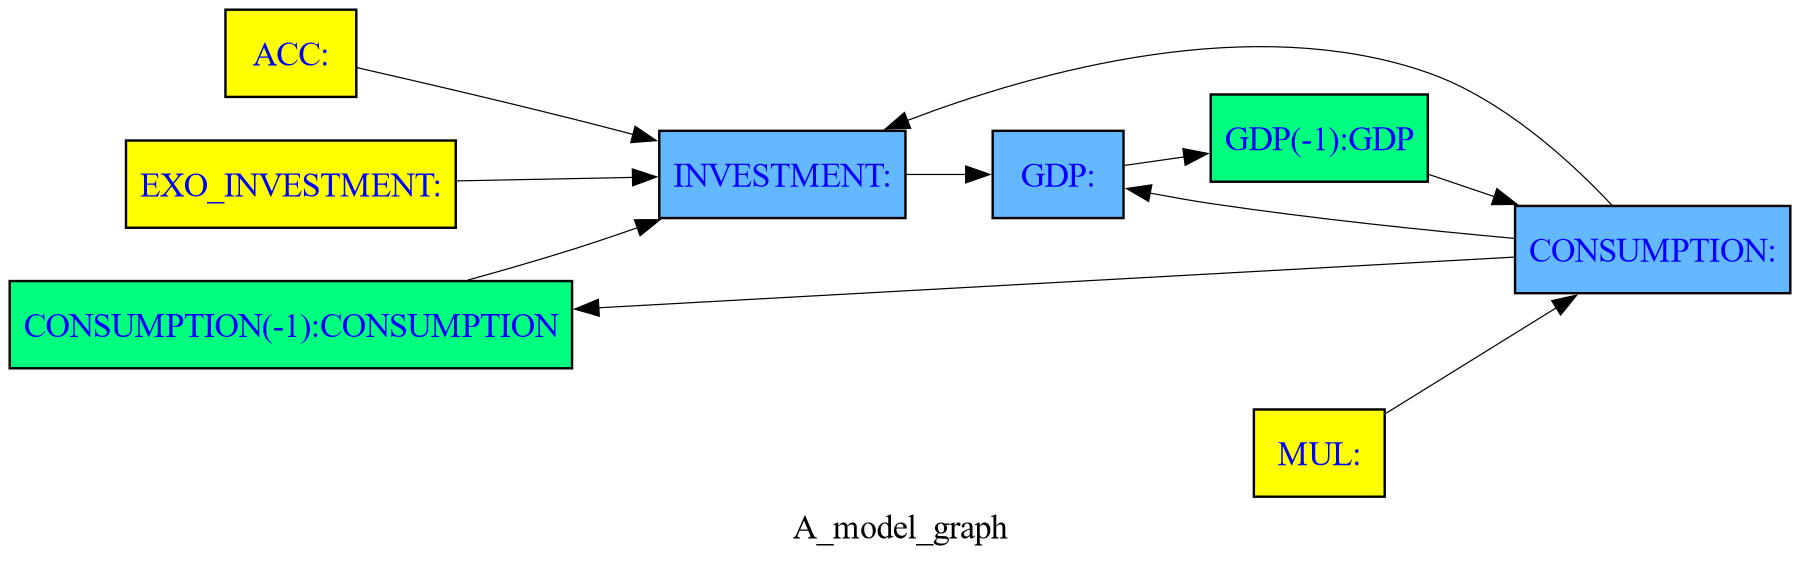

In [4]:
mma = Mmma.mmodel                                   # the solvable modelclass.model instance
mma.name = 'Accelerator multiplicator model'

mma.drawmodel(png=latex)

## Data

We need some data to simulate. `get_df` generates a dataframe with the parameters `MUL` and `ACC`, and with exogenous
investment.


In [5]:
def get_df(mul=0.9, acc=0.5, gdp=1000, im=200, years=100):
    'Creates input dataframe to the accelerator multiplier model'
    df = pd.DataFrame([[gdp]]*years, index=range(2018, 2018+years), columns=['GDP'])
    df.loc[:, 'MUL'] = mul
    df.loc[:, 'ACC'] = acc
    df.loc[:, 'CONSUMPTION'] = gdp*mul
    df.loc[:, 'EXO_INVESTMENT'] = im
    return df


base = get_df()
base.head()

,GDP,MUL,ACC,CONSUMPTION,EXO_INVESTMENT
2018,1000,0.9,0.5,900.0,200
2019,1000,0.9,0.5,900.0,200
2020,1000,0.9,0.5,900.0,200
2021,1000,0.9,0.5,900.0,200
2022,1000,0.9,0.5,900.0,200


## A function which simulates the model and calculates the eigenvalues

This can be ignored if you are not interested in the Python implementation.

:::{note}
A **fresh** `newton_diff` object is created for each experiment. The derivatives - and therefore the companion matrix -
depend on the values of `MUL` and `ACC`, so an object made for an earlier experiment would answer with the eigenvalues of
that experiment. `<modelclass>.get_eigenvalues()` keeps its `newton_diff` object in `<modelclass>.stability_newton` and
reuses it, which is what you want when the same solution is analysed repeatedly, but not here.
:::


In [6]:
def geteigen(mul, acc, years=30, per=2023, show=False):
    '''Solves the Samuelson multiplier-accelerator model and calculates the eigenvalues
    of the companion matrix in order to evaluate stability.

    per is the year for which the companion matrix and the eigenvalues are displayed.
    Returns the newton_diff object, so that it can be used for further analysis.'''

    baseline_not_solved = get_df(mul, acc, years=years)
    baseline = mma(baseline_not_solved, silent=True)          # solve the model

    # newton_diff holds the derivative machinery. A new one is created for each
    # experiment, as the derivatives depend on the values of MUL and ACC.
    newton = mma.get_newton()

    # calculates the companion matrix and its eigenvalues and eigenvectors for each period
    _ = newton.get_eigenvalues(silent=True)

    # a dict: key is the year, value is a dataframe with eigenvalues in the first row
    # and the corresponding eigenvectors below
    eig_dict = newton.get_df_eigen_dict()

    display(Markdown(f'**Model where multiplier = {mul} and accelerator = {acc}**'))
    display(newton.eigenvector_plot(size=(4, 4), per=per))    # show the eigenvalues

    mma['gdp consumption investment'].plot(top=0.8, title='Values', colrow=3, sharey=False)   # show the solution

    if show:
        # The model is linear and time independent, so one year tells the whole story
        eigper = eig_dict[per]

        # a function which calculates a list of absolute values from a column of complex numbers
        compabs = lambda complex: [abs(value) for index, value in complex.items()]

        # only retain the columns where the length of the eigenvalue is above 0.0001
        eigperout = (eigper.
                     T.                                            # transpose, as we query and eval on columns
                     eval('absolute_value=@compabs(Eigenvalues)').  # the absolute value of the eigenvalue
                     query('absolute_value>=0.0001').              # keep the rows where the abs value is above 0.0001
                     drop('absolute_value', axis=1).               # the absolute value is not needed anymore
                     T)                                            # transpose back

        #display(Markdown(f'**Companion matrix M in {per}**'))
        #display(newton.get_df_comp_dict()[per])

        display(Markdown(f'**Non zero eigenvalues and -vectors in {per}**'))
        display(eigperout)

    return newton

## No amplification


**Model where multiplier = 0.8 and accelerator = 0**

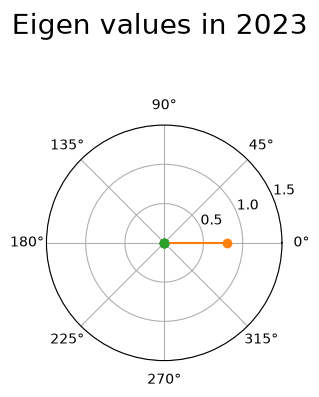

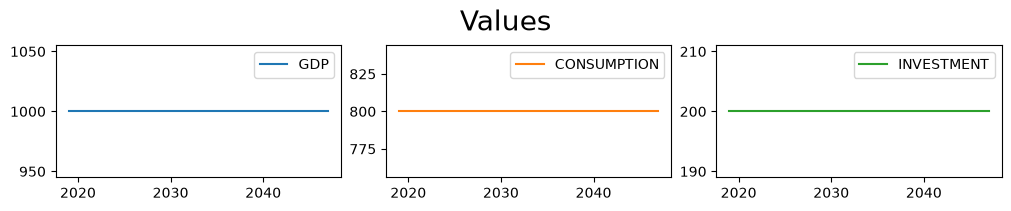

**Non zero eigenvalues and -vectors in 2023**

,1
Eigenvalues,0.800000
CONSUMPTION(-1),0.707107
GDP(-1),0.707107
INVESTMENT(-1),0.000000


In [7]:
geteigen(mul=0.8, acc=0, show=1);

## Explosion


**Model where multiplier = 0.9 and accelerator = 2**

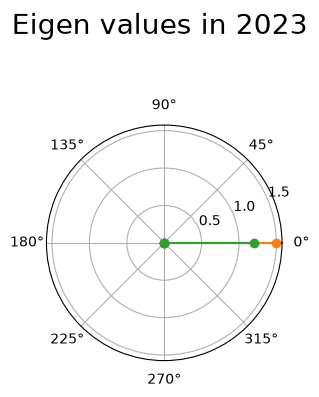

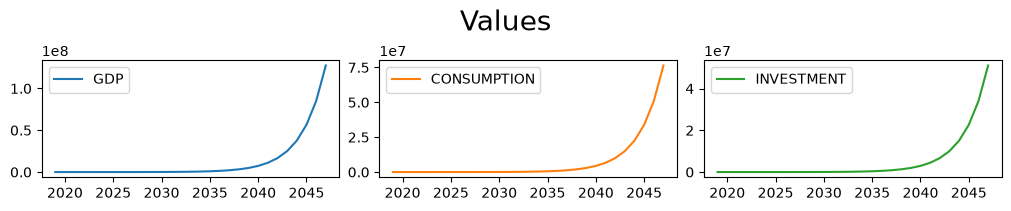

**Non zero eigenvalues and -vectors in 2023**

,1,2
Eigenvalues,1.500000,1.200000
CONSUMPTION(-1),0.486664,0.588348
GDP(-1),0.811107,0.784465
INVESTMENT(-1),0.324443,0.196116


In [8]:
geteigen(mul=0.9, acc=2, show=1);

## Exploding oscillations


**Model where multiplier = 0.6 and accelerator = 2**

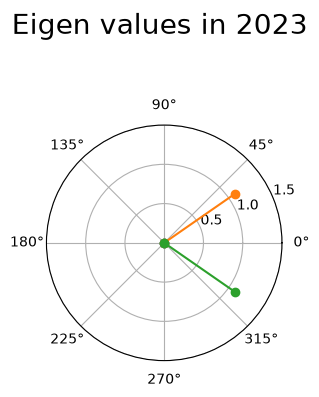

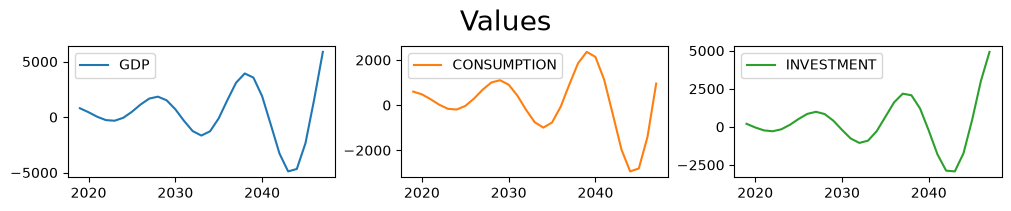

**Non zero eigenvalues and -vectors in 2023**

,1,2
Eigenvalues,0.900000+0.624500j,0.900000-0.624500j
CONSUMPTION(-1),-0.345134+0.239485j,-0.345134-0.239485j
GDP(-1),-0.766965+0.000000j,-0.766965-0.000000j
INVESTMENT(-1),-0.421831-0.239485j,-0.421831+0.239485j


In [9]:
geteigen(mul=0.6, acc=2, show=1);

## Perpetual oscillations


**Model where multiplier = 0.5 and accelerator = 2**

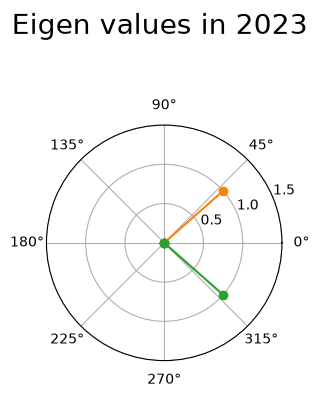

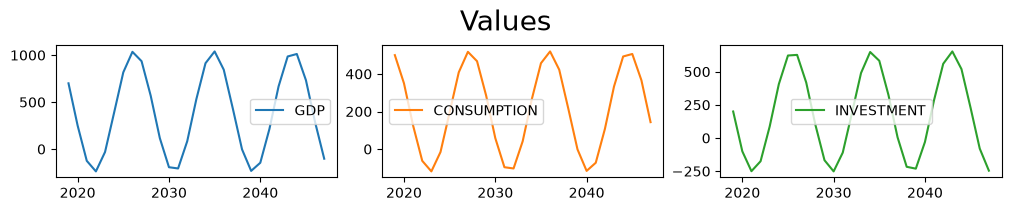

**Non zero eigenvalues and -vectors in 2023**

,1,2
Eigenvalues,0.750000+0.661438j,0.750000-0.661438j
CONSUMPTION(-1),-0.283473+0.250000j,-0.283473-0.250000j
GDP(-1),-0.755929+0.000000j,-0.755929-0.000000j
INVESTMENT(-1),-0.472456-0.250000j,-0.472456+0.250000j


In [10]:
geteigen(mul=0.5, acc=2, show=1);

## Dampened oscillations


**Model where multiplier = 0.7 and accelerator = 1**

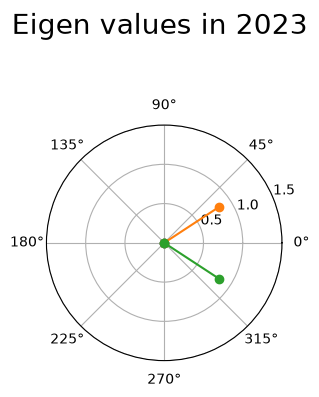

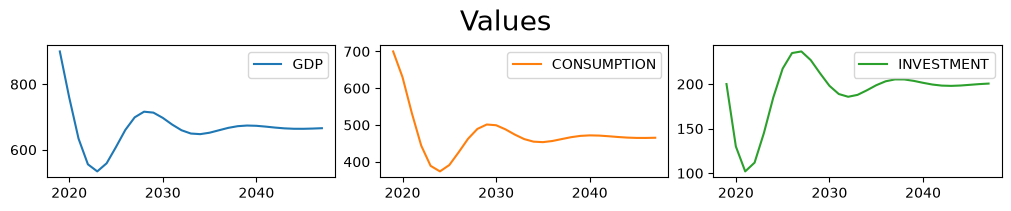

**Non zero eigenvalues and -vectors in 2023**

,1,2
Eigenvalues,0.700000+0.458258j,0.700000-0.458258j
CONSUMPTION(-1),0.494975-0.324037j,0.494975+0.324037j
GDP(-1),0.707107+0.000000j,0.707107-0.000000j
INVESTMENT(-1),0.212132+0.324037j,0.212132-0.324037j


In [11]:
geteigen(mul=0.7, acc=1, show=1);

## Jackknife experiments to identify the impact from each equation

To understand the impact of each equation a jackknife can be made. This is done by deleting the row and the column
belonging to each equation in turn and recording the new eigenvalues.

The idea is to identify the equations which contribute most to the eigenvalues of the whole system.

The `newton_diff` object returned above also performs this operation. `newton.get_eigen_jackknife_abs_select(year)` returns
the sum of the `largest` absolute eigenvalues when each equation in turn is deleted. The row named `NONE` is the value when
no equation is deleted.

:::{note}
The terminology is loosely coined from Jackknife resampling <https://en.wikipedia.org/wiki/Jackknife_resampling>.

Contributions to better naming are very welcome.
:::


**Model where multiplier = 0.6 and accelerator = 2**

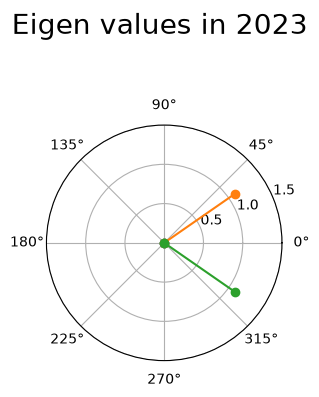

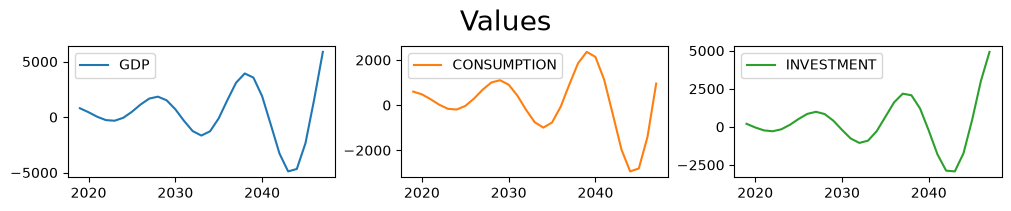

**Non zero eigenvalues and -vectors in 2023**

,1,2
Eigenvalues,0.900000+0.624500j,0.900000-0.624500j
CONSUMPTION(-1),-0.345134+0.239485j,-0.345134-0.239485j
GDP(-1),-0.766965+0.000000j,-0.766965-0.000000j
INVESTMENT(-1),-0.421831-0.239485j,-0.421831+0.239485j


Calculating eigenvalues of 3  different matrices takes time, so make cup of coffee and a take a short nap


  0%|          | 0/3 [00:00<?, ?it/s]

CONSUMPTION    0.00000
GDP            0.00000
INVESTMENT     0.60000
NONE           2.19089
dtype: float64

In [12]:
newton = geteigen(mul=0.6, acc=2, show=1)
newton.get_eigen_jackknife_abs_select(year=2023, largest=2)

The output above shows that the largest eigenvalue of the system is 1.1, so the system is unstable. If either the
consumption or the GDP equation is deleted, the largest $\lvert\lambda\rvert$ will be 0, so the system will not be
unstable. The same goes if the investment equation is excluded - however in that case the largest $\lvert\lambda\rvert$
will be 0.6.

So for such a small model the procedure is not very useful. But for larger models it can help to identify rough equations.
